In [1]:
from diffusers import AutoencoderKL, DDPMScheduler, DiffusionPipeline, UNet2DConditionModel
from diffusers import StableDiffusionPipeline

import os
import torch

/home/nessessence/anaconda3/envs/mace/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nessessence/anaconda3/envs/mace/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
/home/nessessence/anaconda3/envs/mace/lib/py

In [2]:
def load_token_embedding(text_encoder, tokenizer, weight_path):
    # logger.info(f"Loading Token Embeddings from {weight_path}")
    # Load the saved token embeddings
    loaded_embeds_dict = torch.load(weight_path)
    # Get the input embedding layer
    token_embeddings = text_encoder.get_input_embeddings()
    # Process each token
    for token, embed in loaded_embeds_dict.items():
        # Check if token already exists in tokenizer
        token_id = tokenizer.convert_tokens_to_ids(token)
        if token_id == tokenizer.unk_token_id:
            print(f'adding {token} to the tokenizer vocabs')
            # Token doesn't exist, add to tokenizer
            tokenizer.add_tokens([token])
            token_id = tokenizer.convert_tokens_to_ids(token)
            # Resize the embedding layer to match new vocab size
            text_encoder.resize_token_embeddings(len(tokenizer))
        # Set the embedding weight
        with torch.no_grad():
            print(f'loading embedding for {token}')
            token_embeddings.weight[token_id] = embed.to(token_embeddings.weight.device)
            

In [2]:

pretrained_model_name_or_path = "CompVis/stable-diffusion-v1-4"
lora_weight_dir_path = "data_root/logs/c.l4.kv_chiquita50-V_pr0.50_lr5e-4.ti1e-2_f0.5_b1g4/checkpoint-3000"

pipeline = DiffusionPipeline.from_pretrained(pretrained_model_name_or_path)



/home/nessessence/anaconda3/envs/mace/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...: 100%|███████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00,  9.44it/s]


In [3]:
pipeline.to('cuda')


StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.22.0",
  "_name_or_path": "CompVis/stable-diffusion-v1-4",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [3]:
pipeline.unet

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): LoRACompatibleLinear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): LoRACompatibleLinear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): LoRACompatibleConv(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): LoRACompatibleLinear(in_features=320, out_features=320, bias=False)
                (to_k): LoRACompatibleLinear(in_features=320, out_features=320

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


adding v1 to the tokenizer vocabs
loading embedding for v1


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:07<00:00,  7.00it/s]


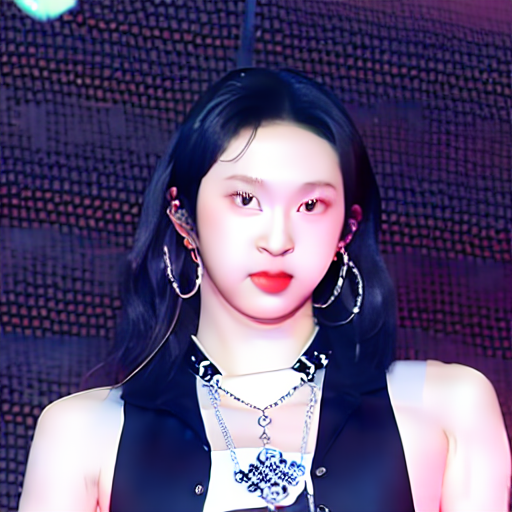

In [12]:
# pipeline.load_lora_weights(lora_weight_dir_path, weight_name="pytorch_lora_weights.safetensors")


token_emb_path = "data_root/logs/c.l4.kv_chiquita50-V_pr0.50_lr5e-4.ti1e-2_f0.5_b1g4/checkpoint-3000"
load_token_embedding(pipeline.text_encoder, pipeline.tokenizer, os.path.join(token_emb_path,'token_embedding.pt'))


display(pipeline('a photo of a v1').images[0])

In [13]:
pipeline.unet

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): LoRACompatibleLinear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): LoRACompatibleLinear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): LoRACompatibleConv(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): LoRACompatibleLinear(in_features=320, out_features=320, bias=False)
                (to_k): LoRACompatibleLinear(in_features=320, out_features=320

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  7.19it/s]


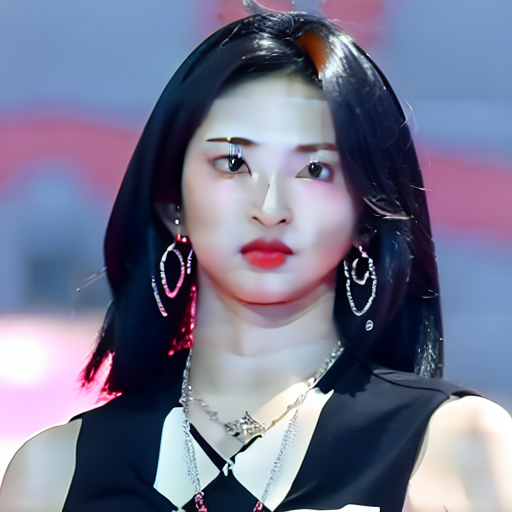

In [14]:
pipeline.fuse_lora()
display(pipeline('a photo of a v1').images[0])

In [15]:
pipeline.unet

UNet2DConditionModel(
  (conv_in): Conv2d(4, 320, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): LoRACompatibleLinear(in_features=320, out_features=1280, bias=True)
    (act): SiLU()
    (linear_2): LoRACompatibleLinear(in_features=1280, out_features=1280, bias=True)
  )
  (down_blocks): ModuleList(
    (0): CrossAttnDownBlock2D(
      (attentions): ModuleList(
        (0-1): 2 x Transformer2DModel(
          (norm): GroupNorm(32, 320, eps=1e-06, affine=True)
          (proj_in): LoRACompatibleConv(320, 320, kernel_size=(1, 1), stride=(1, 1))
          (transformer_blocks): ModuleList(
            (0): BasicTransformerBlock(
              (norm1): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
              (attn1): Attention(
                (to_q): LoRACompatibleLinear(in_features=320, out_features=320, bias=False)
                (to_k): LoRACompatibleLinear(in_features=320, out_features=320

In [16]:
pipeline.save_pretrained("mace_test_lora")


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:07<00:00,  6.47it/s]


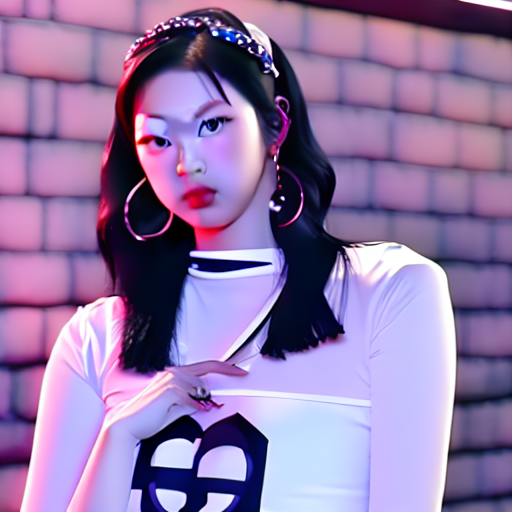

In [2]:

model_path = "mace_test_lora"
lora_pipeline = StableDiffusionPipeline.from_pretrained(model_path, torch_dtype=torch.float32).to('cuda')
display(lora_pipeline('a photo of a v1').images[0])



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  7.19it/s]


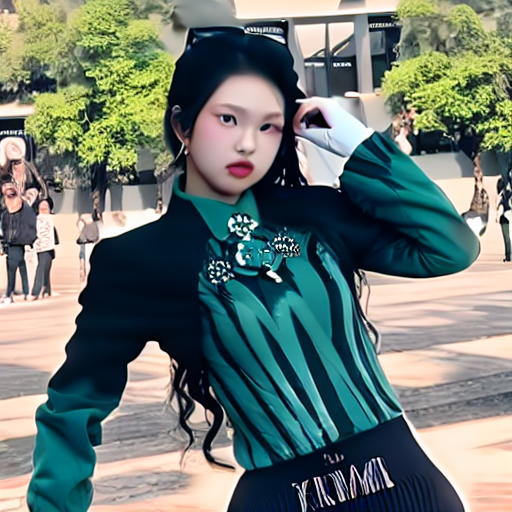

In [3]:
display(lora_pipeline('a photo of a v1').images[0])
